In [2]:
import numpy as np 
import pandas as pd 
import seaborn as sns 
from matplotlib import pyplot as plt 

### KMeans Cluster Algorithm works in 5 steps. 
--- 
1. Decide n number of cluster. `value of k`.
2. Initialize n centroids for n clusters randomly.
3. Take each points and calculate the distance from every cluster and assign the point to the cluster where distance is minimum.
4. Then take every points of a cluster and calculate the mean point which will be the new centroid.
5. Repeat the step 3 and 4, untill centroids at previous step and centroids at current step are different.

In [26]:
class KMeansClusters: 
    def __init__(self , n_clusters = 2 , max_iter = 100 , tolarance = 1e-4): 
        self.n_clusters = n_clusters
        self.max_iter = max_iter
        self.tolarance = tolarance # tolerance to check convergence
        self.centroids = None # List of centroids values
        
    def fit(self , X): 
        self.X = X 
        self.n_samples , self.n_features = X.shape

        # step-01: Initialize centroids randomly from the data points 
        random_indices = np.random.choice(range(self.n_samples) , size = self.n_clusters , replace = False)
        self.centroids = X[random_indices]

        # step-02: repeat the step 3 and 4 until current tolrance is greater than given tolarance 
        for i in range(self.max_iter): 
            # step-03: Assign each point to the nearest centroid 
            self.labels = self._assign_clusters(self.X)

            # step-04: Recalculate the centroids for n_clusters
            # axis = 0 means column wise mean 
            new_centroids = []
            for j in range(self.n_clusters): 
                # get all the data points assigned to cluster j 
                cluster_points = self.X[self.labels == j] 

                # calculate the mean of points in cluster-j axis = 0 means column-wise mean 
                centroid = cluster_points.mean(axis = 0)
                new_centroids.append(centroid)

            new_centroids = np.array(new_centroids)
            # step-05: check for convergence 
            diff = np.linalg.norm(self.centroids - new_centroids)
            if diff < self.tolarance: 
                break

            self.centroids = new_centroids

    def _assign_clusters(self , X): 
        # assign each data point in X to the nearest centroid based on Euclidean distance.
        labels = [] # for every row it will be a value from 0 to n_clusters-1

        # go to each row of X 
        for row in X:
            # Store the distance from this row to every centroid 
            distances = [] # it will store the distance of a row from every centroid 

            # now go to every centroid 
            for centroid in self.centroids: 
                # Find the euclidean distance from row(point) to ccentroid
                distance = np.sqrt(np.sum((row - centroid) ** 2))
                distances.append(distance)
            # Find the index(cluster value) of the nearest centroid for the row 
            nearest_index = np.argmin(distances)
            labels.append(nearest_index)

        return np.array(labels)
        
    def predict(self , X): 
        # when we will get a row again find distance from all the clusters centroid and take the nearest 
        predicted_labels = []
        
        # predict for each row 
        for row in X:
            # go to every centroid and find the distance 
            distances = [] 

            for centroid in self.centroids: 
                distance = np.sqrt(np.sum((row - centroid) ** 2))
                distances.append(distance)
                
            nearest_index = np.argmin(distances)
            predicted_labels.append(nearest_index)

        return np.array(predicted_labels)
            
    def fit_predict(self , X): 
        # first call fit and then return the labels 
        self.fit(X)
        return self.labels

In [3]:
df = pd.read_csv("student_clustering.csv")
df.shape

(200, 2)

In [4]:
X = df.iloc[ : , : ].values
X.shape

(200, 2)

In [5]:
random_indices = np.random.choice(range(X.shape[0]) , size = 3)
random_indices

array([148, 186,  22])

In [6]:
X[random_indices]

array([[  6.38, 107.  ],
       [  7.91,  93.  ],
       [  7.78,  92.  ]])

In [7]:
X[[2 , 5 , 8]]

array([[  8.36,  93.  ],
       [  5.88, 109.  ],
       [  5.79, 110.  ]])

In [8]:
cluster_points = np.array([
    [1, 2 , 3],
    [3, 4 , 4],
    [5, 6 , 3]
])

In [9]:
# if we dont use axis = 0 
cluster_points.mean() # this will give the mean of all points

np.float64(3.4444444444444446)

In [10]:
cluster_points.mean(axis = 1) # row wise mean

array([2.        , 3.66666667, 4.66666667])

In [11]:
cluster_points.mean(axis = 0) # feature wise mean. mean value of all feature

array([3.        , 4.        , 3.33333333])

In [12]:
centroid0 = cluster_points[0]
one_point = np.array([4 , 6 , 2])

np.sqrt(np.sum((one_point - centroid0) ** 2))

np.float64(5.0990195135927845)

In [14]:
from sklearn.datasets import make_blobs
from sklearn.model_selection import train_test_split
from sklearn.metrics import adjusted_rand_score, silhouette_score

In [15]:
# Generate synthetic data with 5 centers
X, y_true = make_blobs(n_samples = 1000, centers = 5, cluster_std = 0.8, random_state = 42)

In [18]:
X.shape

(1000, 2)

In [19]:
y_true.shape

(1000,)

In [20]:
X

array([[ 4.94403712,  2.46163828],
       [ 3.51386948,  1.35091633],
       [-6.26226822, -9.15894369],
       ...,
       [-9.32593752,  7.17394587],
       [ 4.61188804,  3.38981019],
       [-8.01907774,  7.79754447]], shape=(1000, 2))

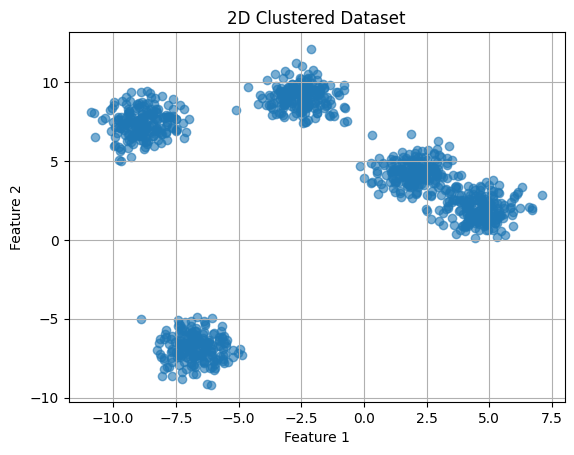

In [21]:
plt.scatter(X[ : , 0] , X[ : , 1] , alpha = 0.6)

plt.title("2D Clustered Dataset")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.grid(True)
plt.show()

In [22]:
X_train, X_test, y_train, y_test = train_test_split(X, y_true, test_size = 0.2 , random_state = 42)

In [27]:
kmeans = KMeansClusters(n_clusters = 5 , max_iter = 100)
kmeans.fit(X_train)
train_labels = kmeans.labels
train_labels

array([1, 1, 0, 2, 3, 1, 3, 1, 2, 3, 2, 4, 3, 4, 3, 1, 2, 3, 2, 2, 1, 0,
       1, 0, 1, 0, 1, 0, 3, 2, 3, 2, 1, 3, 1, 1, 2, 4, 2, 4, 2, 1, 1, 4,
       1, 4, 1, 2, 1, 2, 0, 4, 1, 0, 3, 3, 4, 0, 2, 0, 2, 4, 4, 1, 2, 3,
       4, 4, 2, 3, 2, 4, 3, 0, 2, 3, 3, 2, 2, 2, 2, 4, 2, 3, 1, 3, 2, 4,
       3, 0, 1, 1, 3, 3, 2, 4, 4, 4, 3, 2, 1, 1, 0, 3, 4, 0, 2, 2, 1, 3,
       1, 0, 4, 3, 0, 3, 2, 4, 3, 1, 1, 2, 4, 0, 3, 1, 3, 4, 0, 3, 3, 0,
       4, 3, 2, 0, 1, 2, 3, 4, 2, 4, 4, 0, 0, 1, 3, 3, 2, 2, 4, 4, 1, 2,
       4, 1, 1, 4, 3, 2, 2, 2, 3, 2, 1, 3, 1, 3, 0, 1, 2, 1, 0, 0, 1, 1,
       2, 0, 4, 4, 1, 2, 0, 2, 0, 1, 4, 2, 4, 0, 3, 1, 4, 3, 1, 4, 1, 0,
       1, 1, 4, 2, 0, 4, 3, 4, 1, 1, 1, 2, 1, 4, 1, 2, 2, 1, 2, 4, 3, 3,
       4, 4, 2, 2, 1, 2, 0, 1, 4, 1, 1, 3, 4, 0, 1, 1, 2, 1, 4, 1, 0, 0,
       3, 0, 4, 1, 1, 1, 3, 0, 4, 2, 1, 4, 1, 3, 3, 2, 2, 4, 1, 0, 4, 2,
       4, 4, 1, 0, 2, 3, 0, 2, 0, 1, 1, 3, 1, 2, 4, 3, 2, 3, 0, 1, 2, 0,
       1, 4, 1, 1, 0, 3, 1, 0, 4, 2, 4, 3, 3, 4, 1,

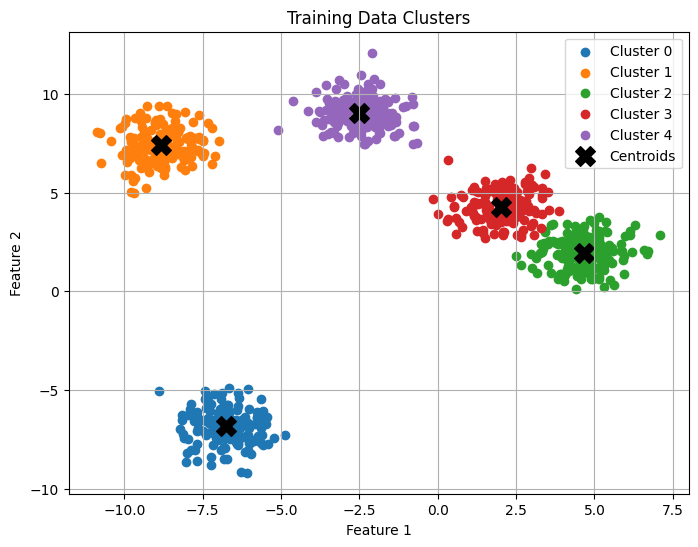

In [28]:
plt.figure(figsize=(8, 6))
plt.title("Training Data Clusters")

for i in range(kmeans.n_clusters):
    plt.scatter(X_train[train_labels == i, 0], X_train[train_labels == i, 1], label=f'Cluster {i}')


plt.scatter(kmeans.centroids[:, 0], kmeans.centroids[:, 1], s=200, c='black', marker='X', label='Centroids')
plt.legend()
plt.grid(True)
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.show()

In [29]:
test_labels = kmeans.predict(X_test)

In [30]:
# Use true cluster labels (from original data) for evaluation
ari = adjusted_rand_score(y_test, test_labels)
silhouette = silhouette_score(X_test, test_labels) 

print(f"Adjusted Rand Index (ARI): {ari:.4f}")
print(f"Silhouette Score: {silhouette:.4f}") 

Adjusted Rand Index (ARI): 0.9766
Silhouette Score: 0.7451


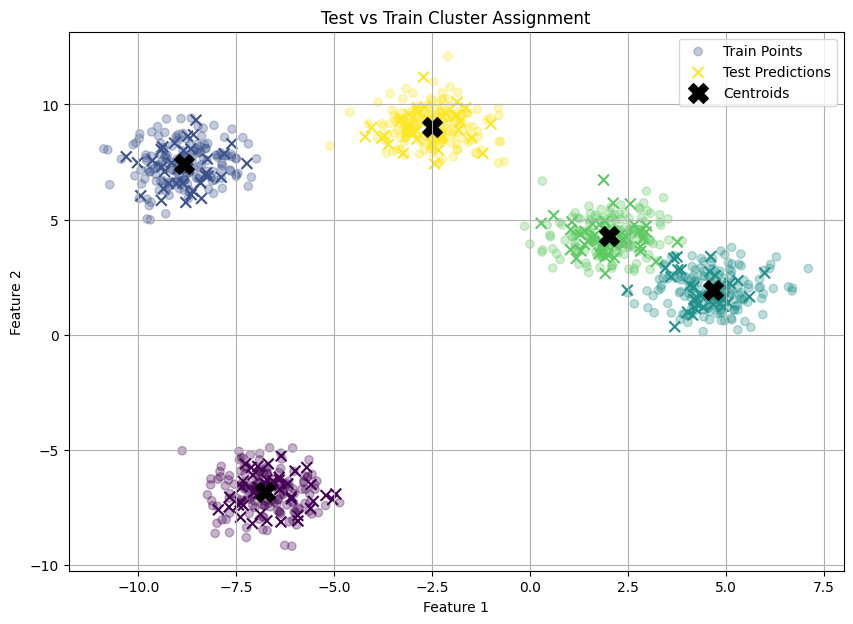

In [31]:
plt.figure(figsize = (10, 7))
plt.title("Test vs Train Cluster Assignment")

# Plot training data
plt.scatter(X_train[:, 0], X_train[:, 1], c=train_labels, cmap='viridis', alpha=0.3, label='Train Points')

# Plot test data with predicted labels
plt.scatter(X_test[:, 0], X_test[:, 1], c=test_labels, cmap='viridis', marker='x', s=60, label='Test Predictions')

# Plot centroids
plt.scatter(kmeans.centroids[:, 0], kmeans.centroids[:, 1], s=200, c='black', marker='X', label='Centroids')

plt.legend()
plt.grid(True)
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.show()